## 1. Load BRIDGE model and compute metrics
Please download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the BRIDGE metrics.

In [ ]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
DATA_DIR="${ROOT_DIR}/dataset"
LOG="results/logs/validate_all.log"
mkdir -p results/logs

: > "$LOG"

for posfile in "$DATA_DIR"/*_pos.fa; do
  data_file="$(basename "$posfile")"
  data_file="${data_file%_pos.fa}"

  echo "Running validate for: ${data_file}" | tee -a "$LOG"

  python main.py \
    --validate \
    --data_path "$DATA_DIR" \
    --data_file "$data_file" \
    --device_num 0 \
    --Transformer_path ./RBPformer \
    --model_save_path ./results/model \
    2>&1 | tee -a "$LOG"
done


Running validate for: AARS_K562
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at ./RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[INFO] Encoded 15000 sequences for AARS_K562, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior: utils/motif_prior/output/AARS_K562/output/STRME_training_set.tab
AARS_K562 auc: 0.7972 acc: 0.7737 auprc: 0.7224 mcc: 0.4605
Running validat

In [ ]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
DATA_DIR="${ROOT_DIR}/dataset"
LOG="results/logs/dynamic_all.log"
mkdir -p results/logs

: > "$LOG"

for posfile in "$DATA_DIR"/*_pos.fa; do
  data_file="$(basename "$posfile")"
  data_file="${data_file%_pos.fa}"

  echo "Running dynamic prediction for: ${data_file}" | tee -a "$LOG"

  python main.py \
    --dynamic_predict \
    --data_path "$DATA_DIR" \
    --data_file "$data_file" \
    --device_num 1 \
    --Transformer_path ./RBPformer \
    --model_save_path ./results/model \
    2>&1 | tee -a "$LOG"
done


Running dynamic prediction for: AARS_K562
Model file does not exitsts! Please train first and save the model
Running dynamic prediction for: AUH_HepG2
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at ./RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[INFO] Encoded 15002 sequences for AUH_HepG2, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior: utils/motif_prior/out

In [1]:
library(ggplot2)
library(ggpubr)
library(readxl)

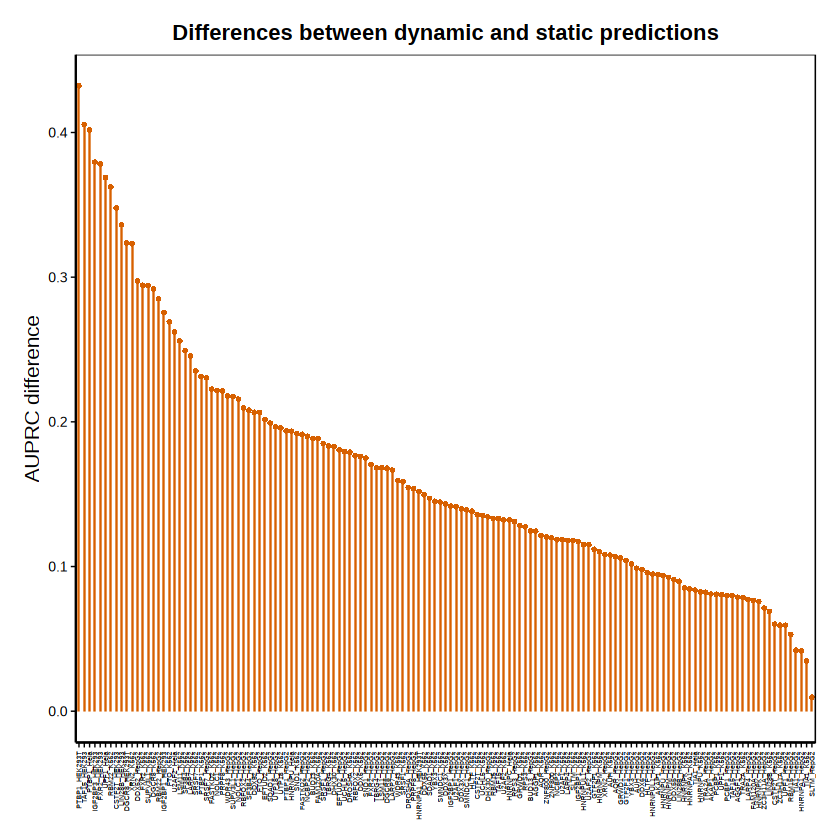

In [2]:
dfm <- read_excel(
  "/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/results/metrics/BRIDGE_Dynamic_vs_Static_Diff_sorted.xlsx",
  sheet = "Sheet1"
)

p <- ggdotchart(
        dfm, x = "x", y = "y",
        xlab = FALSE, ylab = "AUPRC difference", sorting = "none",
        dot.size = 1,
        color = "#d76000", shape = 16, repel = TRUE,
        add = "segments",
        add.params = list(color = "#d76000", linewidth = 0.3, linetype = 1)
      ) +
  geom_point(
        data = subset(dfm, y == max(dfm$y)),
        aes(x = x, y = y),
        color = "#d76000", size = 0.5, shape = 17
      ) +
  theme(
    axis.text.x   = element_text(angle = 90, vjust = 0.5, size = 4),
    axis.text.y   = element_text(size = 8, hjust = 0),
    panel.border  = element_rect(color = "black", fill = NA, linewidth = 0.4), 
    axis.ticks    = element_line(linewidth = 0.3),                               
    plot.margin   = margin(15, 15, 15, 15),
    plot.title    = element_text(size = 13, face = "bold", hjust = 0.5)
  ) +
  ggtitle("Differences between dynamic and static predictions")

p
